In [1]:
import pandas as pd
import numpy as np
import torch.nn as nn

## 1. Data Preprocessing

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data = data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(df.info())
print(df.describe())
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

## 2. Train-test-split and Scaling

In [4]:
X = df
y = data.target

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Tensors and DataLoading

In [7]:
from torch.utils.data import TensorDataset, DataLoader
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [8]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## 4. Model Architecture

In [10]:
class ANNClassification(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(30,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.ReLU(),
            nn.Linear(8,1),
        )

    def forward(self, x):
        return self.model(x)


## 5. Model Training

In [11]:
import torch.optim as optim

model = ANNClassification()

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
epochs = 50
best_epoch = 0
best_accuracy = 0
training_losses = []
validation_losses = []

for epoch in range(epochs):

    model.train()
    running_training_loss = 0.0
    validation_running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()
        
        outputs = model(xb)

        yb = yb.view(-1,1).float()

        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_training_loss += loss.item()

    epoch_running_loss = running_training_loss / len(train_loader)
    training_losses.append(epoch_running_loss)
    print(f'loss = {epoch_running_loss} for epoch = {epoch+1}')

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:

            outputs = model(xb)

            loss = criterion(outputs, yb)
            validation_running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            predicted = (probs >= 0.5).float()

            correct += (predicted == yb).sum().item()
            total += yb.size(0)
        
        epoch_running_loss = validation_running_loss / len(test_loader)
        validation_losses.append(epoch_running_loss)
        accuracy = correct / total * 100

        if accuracy > best_accuracy :
            best_accuracy = accuracy
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model.pt')

        print(f'accuracy for epoch {epoch+1} : {accuracy}\n')

print(f'best accuracy of {best_accuracy} was achieved at epoch = {best_epoch}')

loss = 0.6663600444793701 for epoch = 1
accuracy for epoch 1 : 62.28070175438597

loss = 0.6413593053817749 for epoch = 2
accuracy for epoch 2 : 62.28070175438597

loss = 0.5995816349983215 for epoch = 3
accuracy for epoch 3 : 62.28070175438597

loss = 0.5002717057863871 for epoch = 4
accuracy for epoch 4 : 62.28070175438597

loss = 0.38526877760887146 for epoch = 5
accuracy for epoch 5 : 68.42105263157895

loss = 0.31083241005738577 for epoch = 6
accuracy for epoch 6 : 94.73684210526315

loss = 0.20276124427715939 for epoch = 7
accuracy for epoch 7 : 98.24561403508771

loss = 0.11027955121050279 for epoch = 8
accuracy for epoch 8 : 98.24561403508771

loss = 0.07706946730613709 for epoch = 9
accuracy for epoch 9 : 97.36842105263158

loss = 0.06886131173620622 for epoch = 10
accuracy for epoch 10 : 99.12280701754386

loss = 0.06222582530851165 for epoch = 11
accuracy for epoch 11 : 98.24561403508771

loss = 0.053131478202218814 for epoch = 12
accuracy for epoch 12 : 98.24561403508771

l

## 6. Training vs Validation losses plot

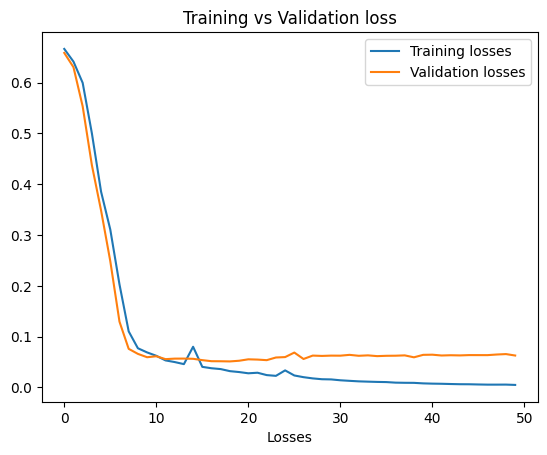

In [13]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    'Training losses' : training_losses,
    'Validation losses' : validation_losses
})

plt.plot(loss_df['Training losses'], label = 'Training losses')
plt.plot(loss_df['Validation losses'], label = 'Validation losses')

plt.xlabel('Epochs')
plt.xlabel('Losses')

plt.title("Training vs Validation loss")

plt.legend()

## 7. Model evaluation

In [ ]:
model.load_state_dict(torch.load('best_model.pt'))

model.eval()
with torch.no_grad():
    training_outputs = model(X_train_tensor)
    probs = torch.sigmoid(training_outputs)
    y_pred = (probs >= 0.5).float()
    
    testing_outputs = model(X_test_tensor)
    probs = torch.sigmoid(testing_outputs)
    y_pred = (probs >= 0.5).float()

    training_bce_loss = criterion(training_outputs, y_train_tensor)
    testing_bce_loss = criterion(testing_outputs, y_test_tensor)

print("Training BCE:", training_bce_loss.item())
print("Testing BCE:", testing_bce_loss.item())


Training BCE: 0.0612947940826416
Testing BCE: 0.061340101063251495


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9912280701754386
Precision: 0.9861111111111112
Recall: 1.0
F1 Score: 0.993006993006993


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[42  1]
 [ 0 71]]


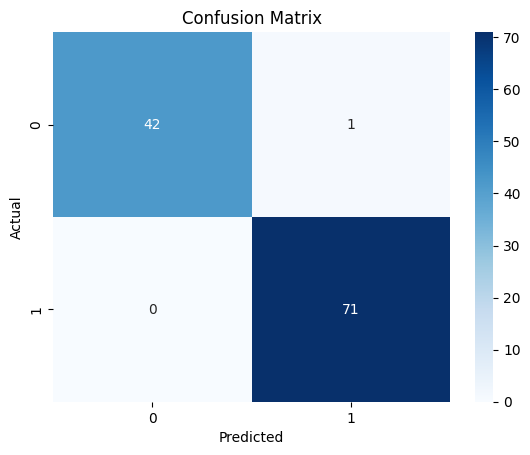

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()